**Overview**

In this section, we explore the Customer Purchasing Behaviors dataset to understand customer demographics, purchasing trends, and loyalty patterns across regions.
The goal is to uncover early insights that will guide feature selection and inform our clustering strategy.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Load dataset
cp = pd.read_csv("C:/Users/schae/dsi/customer_purchasing_behaviors/data/raw/Customer Purchasing Behaviors.csv")

# Preview data
cp.head()


,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency
0,1,25,45000,200,4.5,North,12
1,2,34,55000,350,7.0,South,18
2,3,45,65000,500,8.0,West,22
3,4,22,30000,150,3.0,East,10
4,5,29,47000,220,4.8,North,13


In [24]:
cp.info()
cp.describe(include="all")
cp.isnull().sum()
cp.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             238 non-null    int64  
 1   age                 238 non-null    int64  
 2   annual_income       238 non-null    int64  
 3   purchase_amount     238 non-null    int64  
 4   loyalty_score       238 non-null    float64
 5   region              238 non-null    object 
 6   purchase_frequency  238 non-null    int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 13.1+ KB


np.int64(0)

Dataset contains 238 entries and 7 variables
No missing or duplicate values detected

In [25]:
num_cols = ["age", "annual_income", "purchase_amount", "purchase_frequency", "loyalty_score"]
cp[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
age,238.0,38.676471,9.351118,22.0,31.0,39.0,46.750,55.0
annual_income,238.0,57407.563025,11403.875717,30000.0,50000.0,59000.0,66750.000,75000.0
purchase_amount,238.0,425.630252,140.052062,150.0,320.0,440.0,527.500,640.0
purchase_frequency,238.0,19.798319,4.562884,10.0,17.0,20.0,23.000,28.0
loyalty_score,238.0,6.794118,1.899047,3.0,5.5,7.0,8.275,9.5


Age: Typical customers are in the 31- 47 range.

Annual Income: Slightly right-skewed, with a few high earners.

Purchase Amount: Wide range, suggesting varying spending capacity.

Purchase Frequency: Most customers shop around 20 times/year.

Loyalty Score: Roughly centered around 6.8.

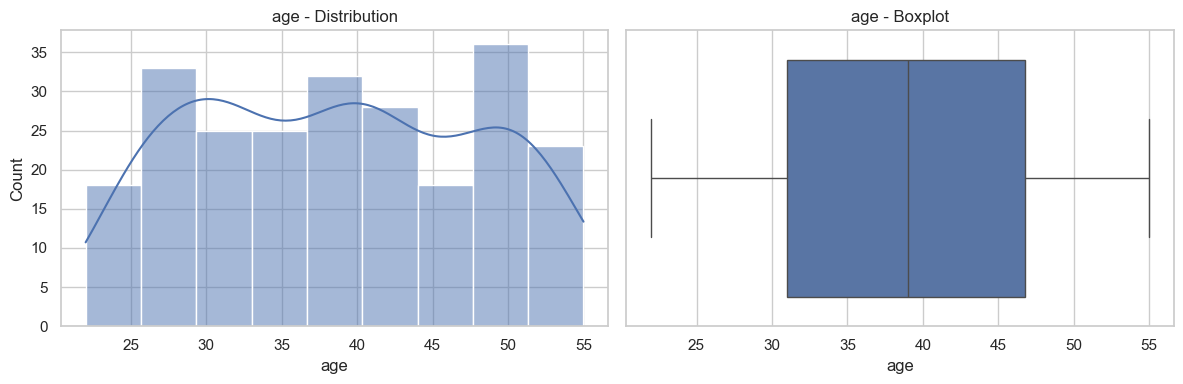

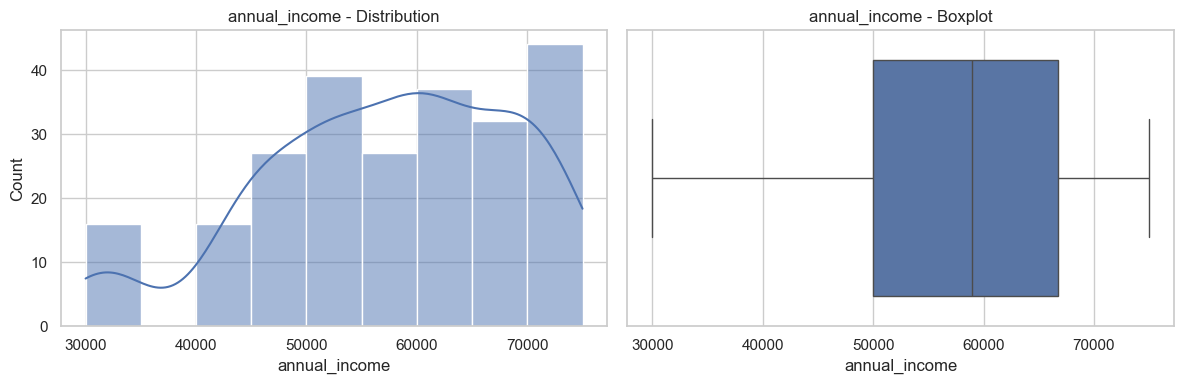

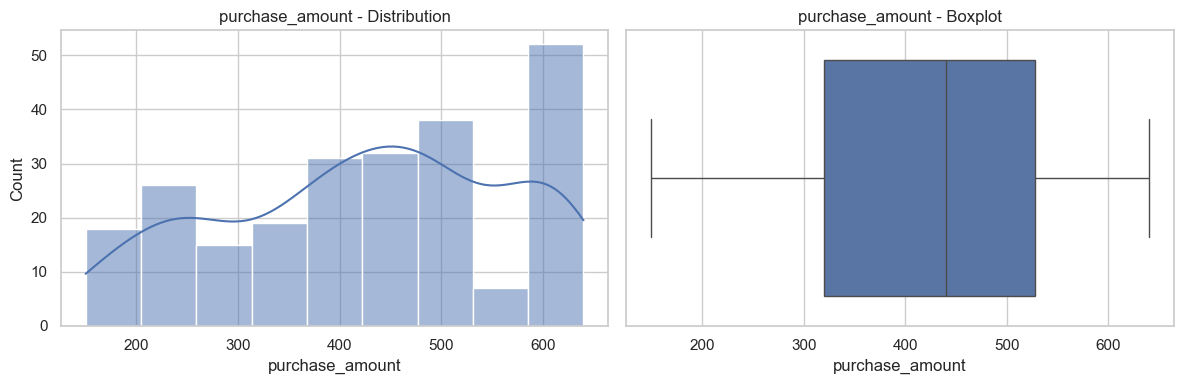

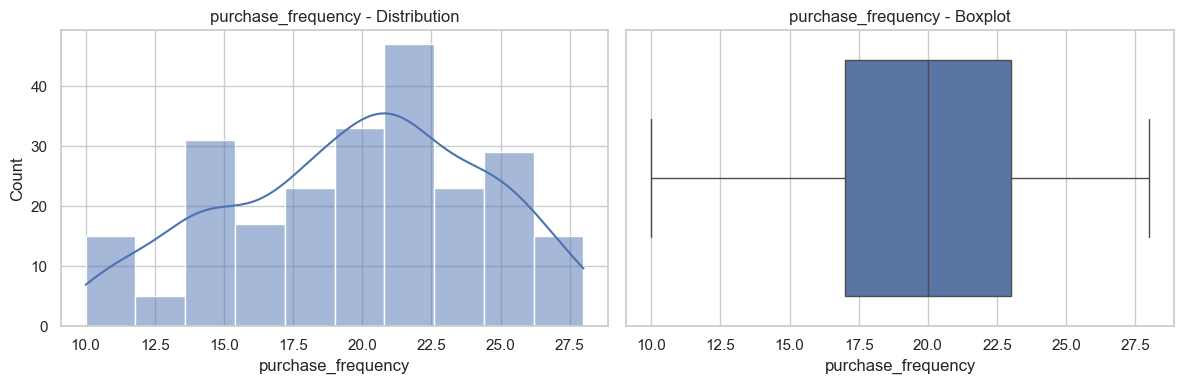

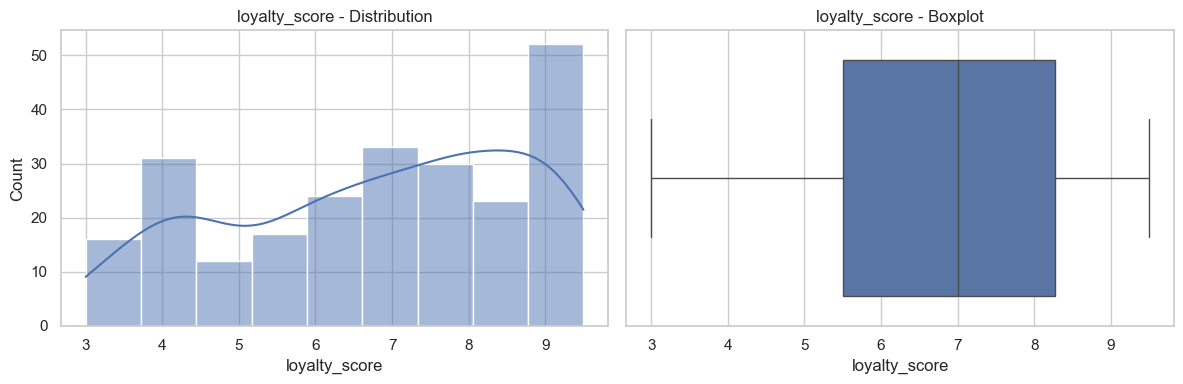

In [26]:
for col in num_cols:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(cp[col], kde=True, ax=ax[0])
    sns.boxplot(x=cp[col], ax=ax[1])
    ax[0].set_title(f"{col} - Distribution")
    ax[1].set_title(f"{col} - Boxplot")
    plt.tight_layout()
    plt.show()


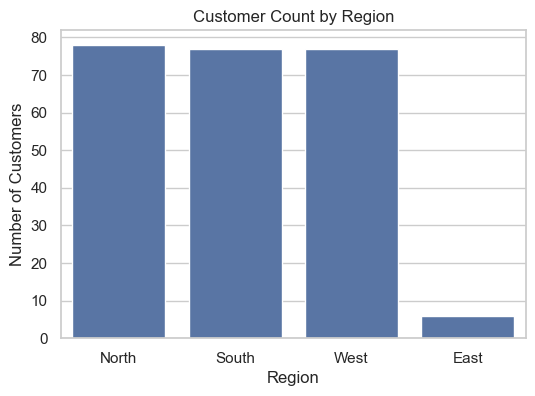

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(x="region", data=cp)
plt.title("Customer Count by Region")
plt.xlabel("Region")
plt.ylabel("Number of Customers")
plt.show()


Regions are relatively balanced with one outlier in the East.
Could help us understand expansion potential.

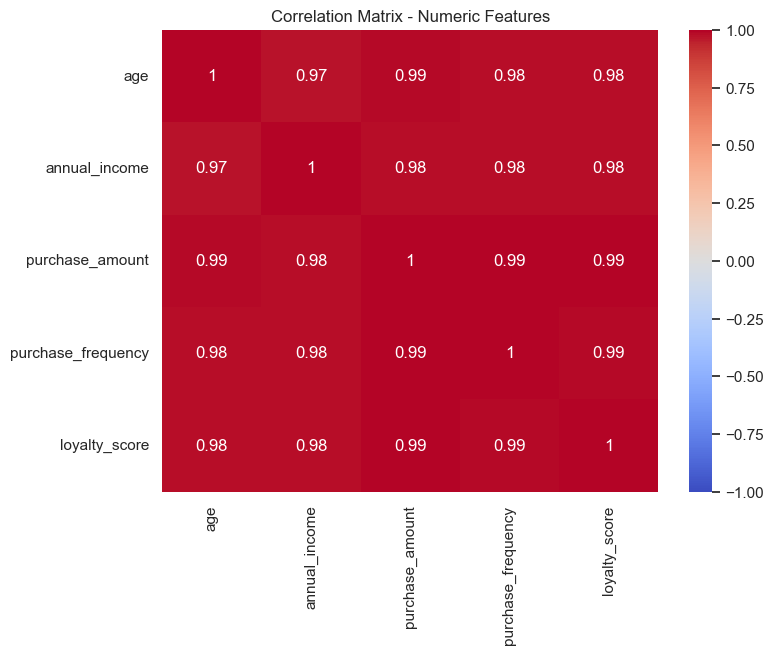

In [28]:
plt.figure(figsize=(8,6))
corr = cp[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix - Numeric Features")
plt.show()


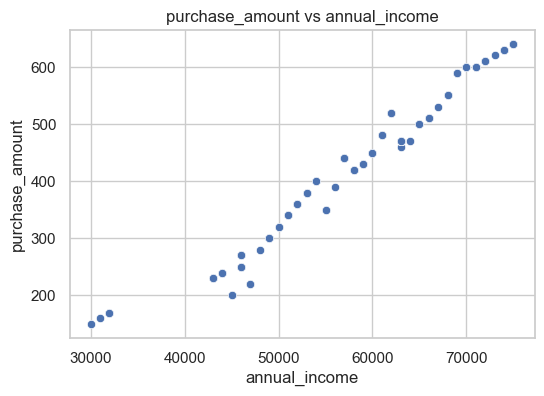

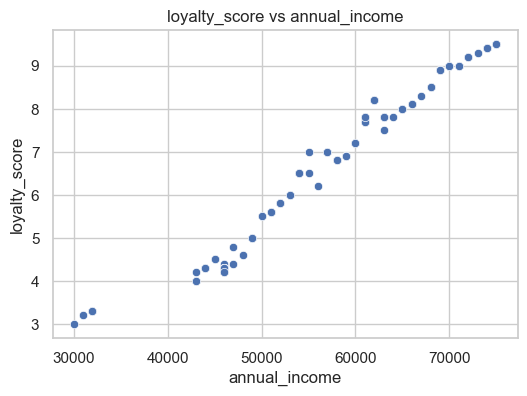

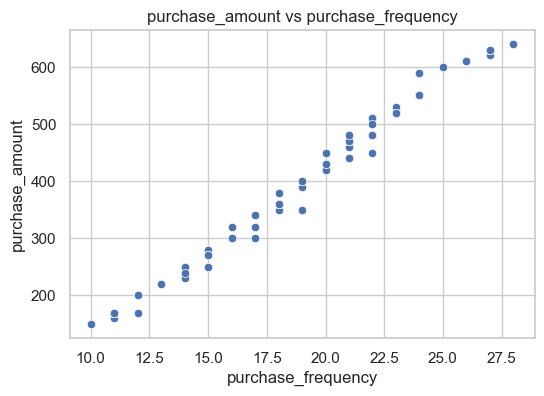

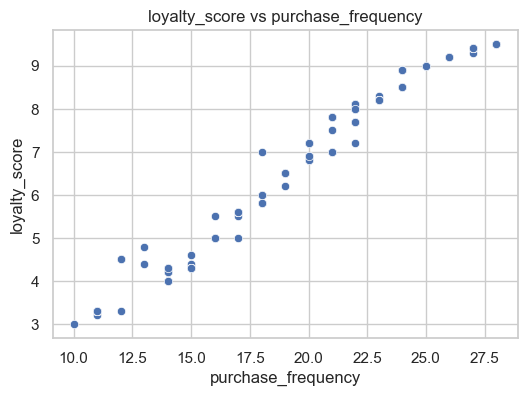

In [29]:
pairs = [
    ("annual_income", "purchase_amount"),
    ("annual_income", "loyalty_score"),
    ("purchase_frequency", "purchase_amount"),
    ("purchase_frequency", "loyalty_score")
]

for x, y in pairs:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=cp[x], y=cp[y])
    plt.title(f"{y} vs {x}")
    plt.show()


Clear upward trend between income and spending.

Frequent shoppers often have higher loyalty scores.

Some clustering patterns already visible — good sign for K-Means

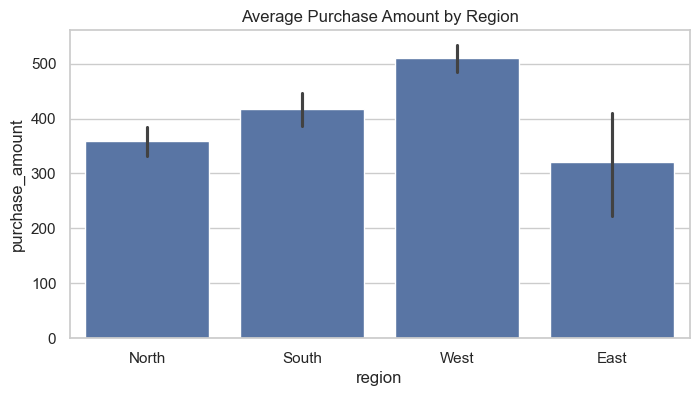

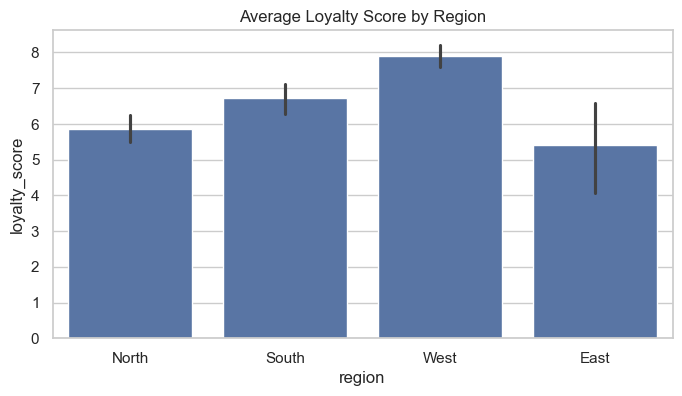

In [30]:
plt.figure(figsize=(8,4))
sns.barplot(x="region", y="purchase_amount", data=cp, estimator=np.mean)
plt.title("Average Purchase Amount by Region")
plt.show()

plt.figure(figsize=(8,4))
sns.barplot(x="region", y="loyalty_score", data=cp, estimator=np.mean)
plt.title("Average Loyalty Score by Region")
plt.show()
